# Imports and Loading Dataset

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# loading the iris dataset and separating the features and target variable into X and y, respectively
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# creating data frame for easier manipulation and visualization
df = pd.DataFrame(X_iris, columns=iris.feature_names)
df['target'] = y_iris
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# creating the data folder if it doesn't exist
Path('..\\data').mkdir(exist_ok=True)

# saving the df as a csv file and storing it in the data folder for documentation purposes
pd.DataFrame(df).to_csv('..\\data\\df.csv', index=False)

# Pre-processing

## Looking for Missing and Duplicated Values

In [28]:
# looking for misses and duplicated values
total_missing = df.isnull().sum().sum()
if total_missing > 0:
    print(f"There are {total_missing} missing values in the dataset.")
    
    # removing rows with missing values
    df.dropna(inplace=True)

duplicated_rows = df[df.duplicated(keep=False)]
if not duplicated_rows.empty:
    
    # if there are duplicated rows, print them
    print("these are the duplicated rows in the dataset:")
    print(duplicated_rows)

    # removing duplicated rows
    df.drop_duplicates(inplace=True)
else:
    print("There are no duplicated rows in the dataset.")

# separating the features and target variable into X and y, respectively
X = df.drop(columns=['target', 'target_name']).values
y = df['target'].values

pd.DataFrame(X).to_csv('..\\data\\X.csv', index=False)
pd.DataFrame(y).to_csv('..\\data\\y.csv', index=False)

these are the duplicated rows in the dataset:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
101                5.8               2.7                5.1               1.9   
142                5.8               2.7                5.1               1.9   

     target target_name  
101       2   virginica  
142       2   virginica  


## Creating a Correlation Matrix and a Pairplot

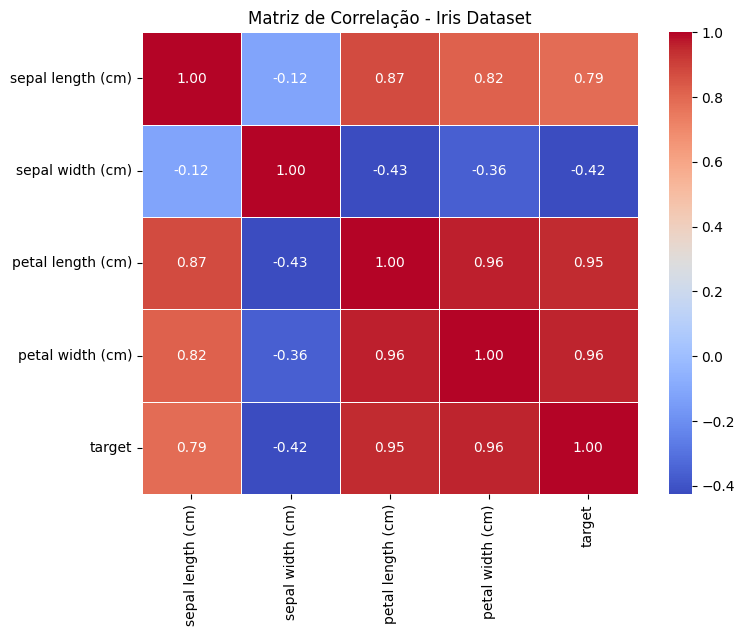

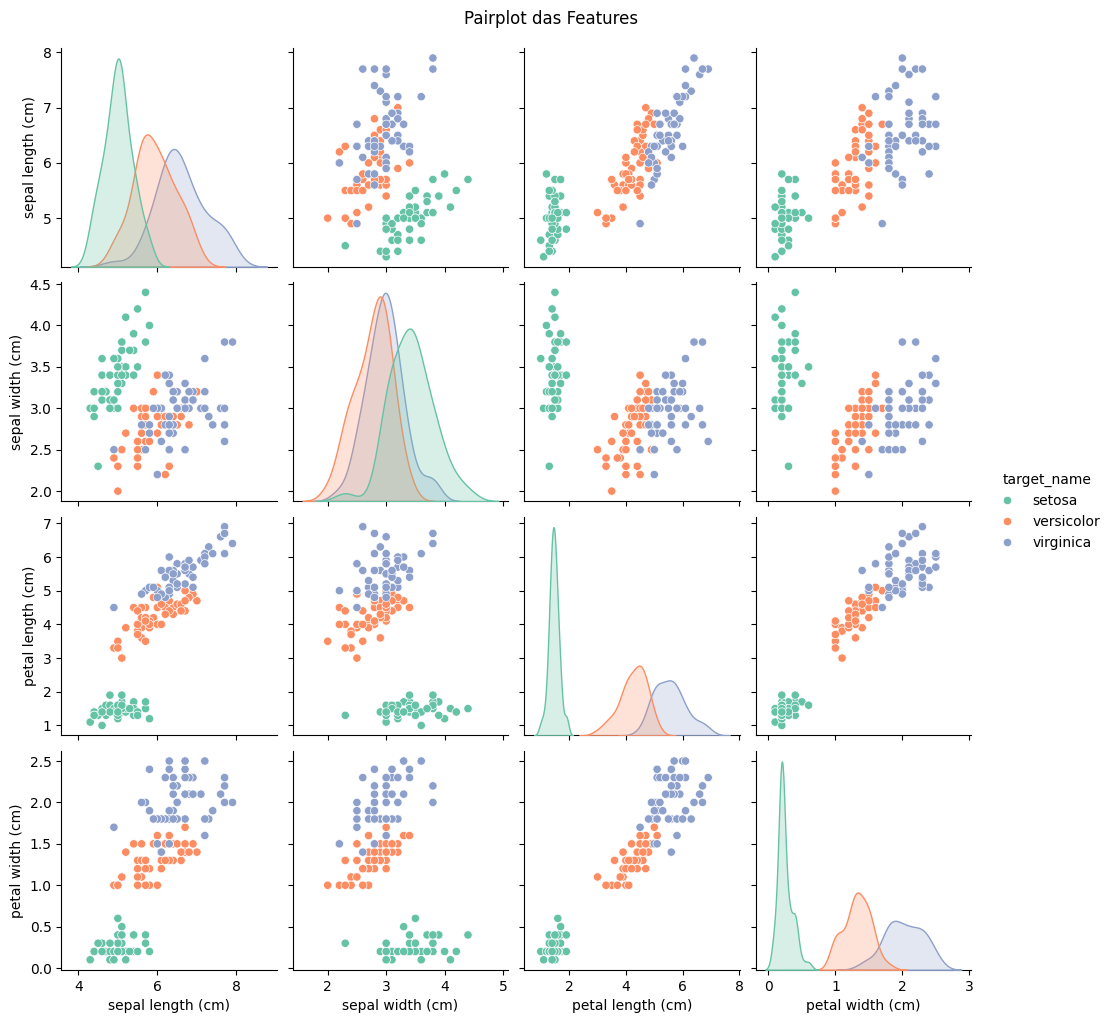

In [ ]:
# making a quick exploratory data analysis (EDA) to understand the relationships between features and the target variable

# creating a correlation matrix heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df.drop(columns=['target_name']).corr(method = 'pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Iris Dataset")
plt.show()

# creating a pairplot to visualize the relationships between features and the target variable
sns.pairplot(df.drop(columns=['target']), hue='target_name', palette='Set2')
plt.suptitle("Pairplot of Features", y=1.02)
plt.show()

## Splitting the Train and Test Data

In [30]:
# splitting the data into training and testing sets with a test size of 20% and a random state of 42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 119 samples
Testing set size: 30 samples


## Normalization Using Standard Scaler and Saving to a CSV File

In [31]:
# scaling the features using StandardScaler, which standardizes the features helping the MLP cause it is sensitive to the scale of the input data. It will transform the features to have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()

# using 'fit_transform' only on the training data to compute the mean and standard deviation, and then scale the training data accordingly without leaking information from the test set.
X_train_scaled = scaler.fit_transform(X_train)

# here we use 'transform' on the test data to scale it using the same mean and standard deviation computed from the training data, ensuring that the test data is scaled in the same way as the training data without introducing any bias.
X_test_scaled = scaler.transform(X_test)

# saving the scaled data for later use in the MLP model training and evaluation
pd.DataFrame(X_train_scaled).to_csv('..\\data\\X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled).to_csv('..\\data\\X_test_scaled.csv', index=False)

## PCA Analysis to See the Linear Separation of the Dataset

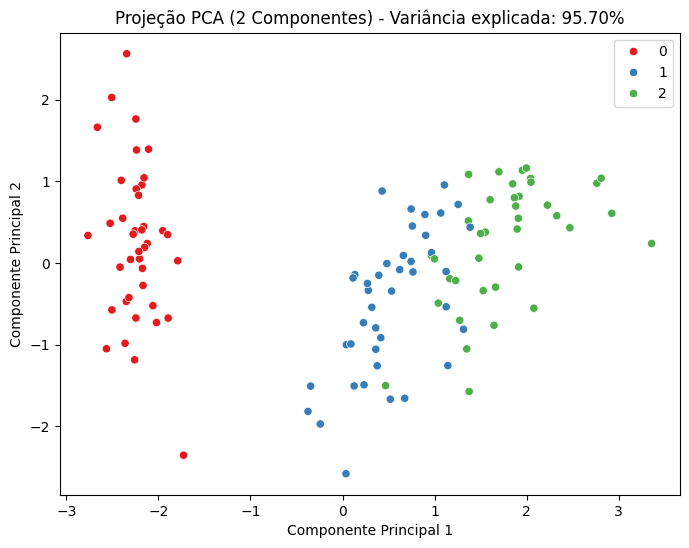

In [ ]:
# choosing to visualize the training data in a 2D space using PCA (Principal Component Analysis) to see how well the classes are separated visually and to understand the variance explained by the first two principal components.
pca = PCA(n_components=2)

# creating a new variable called X_train_pca to store the transformed training data after applying PCA, which will allow us to visualize the data in a 2D space while retaining as much variance as possible.
X_train_pca = pca.fit_transform(X_train_scaled)

# plotting the PCA projection of the training data, coloring the points by their corresponding class labels to visually assess how well the classes are separated in the reduced 2D space, and also displaying the percentage of variance explained by the first two principal components in the title for better understanding of the data representation.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set1', legend='full')
plt.title(f"PCA Projection (2 Components) - Explained Variance: {sum(pca.explained_variance_ratio_) * 100:.2f}%")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Encoding the y Values so It Can Be Used for the MLP Training

In [33]:
# encoding the target variable using OneHotEncoder, which will convert the class labels into a binary matrix representation suitable for multi-class classification with MLP.
encoder = OneHotEncoder(sparse_output=False)

# reshaping y_train and y_test to be 2D arrays with a single column, as required by OneHotEncoder, and then fitting the encoder on the training labels and transforming both the training and testing labels to get the one-hot encoded representations.
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

print(f"Original class (first 3 samples):\n {y_train[:3]}")
print(f"Encoded format (first 3 samples):\n {y_train_encoded[:3]}")

# saving the encoded labels for later use in the MLP model training and evaluation
pd.DataFrame(y_train_encoded).to_csv('..\\data\\y_train_encoded.csv', index=False)
pd.DataFrame(y_test_encoded).to_csv('..\\data\\y_test_encoded.csv', index=False)

Original class (first 3 samples):
 [0 0 1]
Encoded format (first 3 samples):
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]
